# CD: CP-GEN vs GroupMean

For each k=5 cluster we run CP-GEN validation for each CD major gene
(NOD2, ATG16L1, IL23R) and plot the **predicted per-genome variant count** for every genome in the held-out population.

- **CP-GEN**: predicts per genome, so the value varies from genome to genome. 
- **GroupMean**: predicts the cluster train mean, so it is a flat line (same for every genome of the held-out population).


In [1]:
import sys
from os.path import join
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')

from mylib import genomes  # per-population genome-ID lists

In [2]:
# Configuration
cd_root_dir = join(Path.home(), 'projects/cp_als/second_pair/populations/output/CD')
cluster_file = 'cd_population2cluster_AggCluster_k5.csv'
plot_dir = Path('plot')
plot_dir.mkdir(exist_ok=True)

target_genes = ['NOD2', 'ATG16L1', 'IL23R']  # CD major genes
major_genes = ['NOD2', 'ATG16L1', 'IL23R', "STAT3"]   # all excluded from features to avoid trivial leakage

cluster_labels = {
    0: 'American',
    1: 'South Asian',
    2: 'East Asian',
    3: 'African',
    4: 'European',
}

# CP-GEN model choices: (short name for filename, display name, factory)
model_configs = [
    # ('RandomForest', 'Random Forest',
    #  lambda: RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)),
    ('LinearRegression', 'Linear Regression',
     lambda: LinearRegression()),
]

In [3]:
# Load cluster assignments
cluster_df = pd.read_csv(cluster_file)
clusters = {
    cid: cluster_df[cluster_df['Cluster'] == cid]['Population'].tolist()
    for cid in sorted(cluster_df['Cluster'].unique())
}
for cid, pops in clusters.items():
    print(f"Cluster {cid} ({cluster_labels.get(cid, cid)}): {', '.join(pops)}")

Cluster 0 (American): CLM, MXL, PEL, PUR
Cluster 1 (South Asian): BEB, GIH, ITU, PJL, STU
Cluster 2 (East Asian): CDX, CHB, CHS, JPT, KHV
Cluster 3 (African): ACB, ASW, ESN, GWD, LWK, MSL, YRI
Cluster 4 (European): FIN, GBR, IBS, TSI


In [4]:
def load_population(pop):
    """Return a DataFrame indexed by genome ID with one column per gene (summed variant counts)."""
    odf = pd.read_csv(join(cd_root_dir, f'{pop}/all.csv'))
    odf = odf[genomes[pop] + ['gene']]
    sdf = odf.groupby(['gene']).sum().transpose()
    sdf['population'] = pop
    return sdf

def build_cluster_frame(pops):
    return pd.concat([load_population(p) for p in pops])

In [5]:
def predict_cluster(pops, gene, model_factory):
    cdf = build_cluster_frame(pops)
    gene_cols = [c for c in cdf.columns if c != 'population']
    feats = [g for g in gene_cols if g not in major_genes]

    records = []
    for held_out in pops:
        train = cdf[cdf['population'] != held_out]
        test = cdf[cdf['population'] == held_out]
        if len(pops) < 2 or len(train) == 0:
            continue

        X_train, y_train = train[feats].values, train[[gene]].values
        X_test, y_test = test[feats].values, test[[gene]].values

        x_scaler, y_scaler = StandardScaler(), StandardScaler()
        X_train_s = x_scaler.fit_transform(X_train)
        y_train_s = y_scaler.fit_transform(y_train).ravel()
        X_test_s = x_scaler.transform(X_test)

        model = model_factory()
        model.fit(X_train_s, y_train_s)
        y_pred = y_scaler.inverse_transform(model.predict(X_test_s).reshape(-1, 1)).ravel()

        train_mean = train[gene].mean()  # GroupMean: mean of TRAIN genomes for this fold
        for gid, actual, pred in zip(test.index, y_test.ravel(), y_pred):
            records.append({'genome': gid, 'test_population': held_out,
                            'actual': actual, 'cpgen': pred, 'group_mean': train_mean})

    return pd.DataFrame(records).reset_index(drop=True)

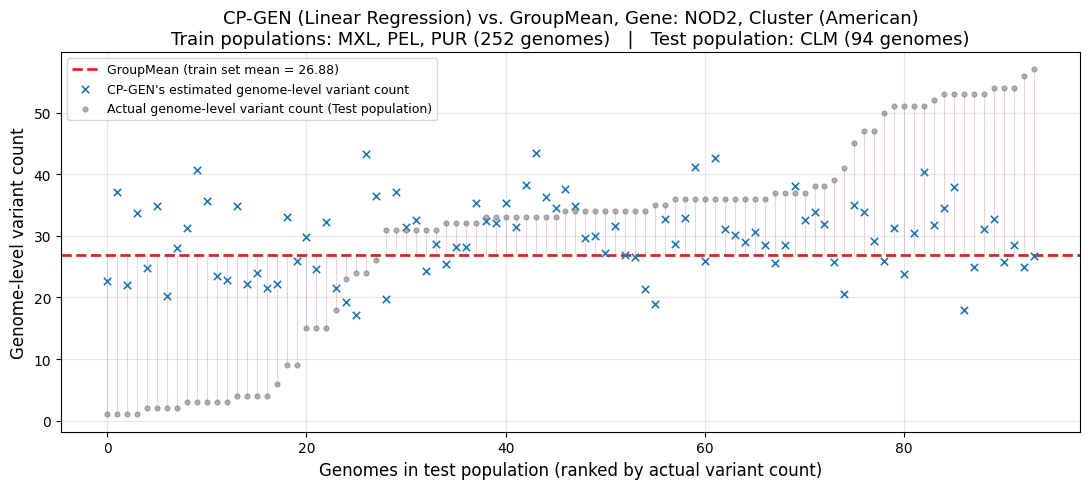

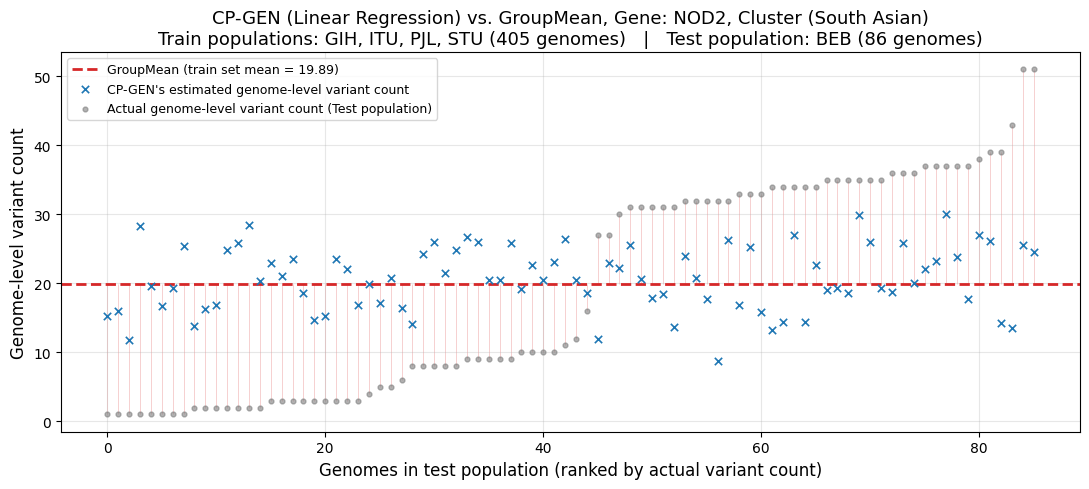

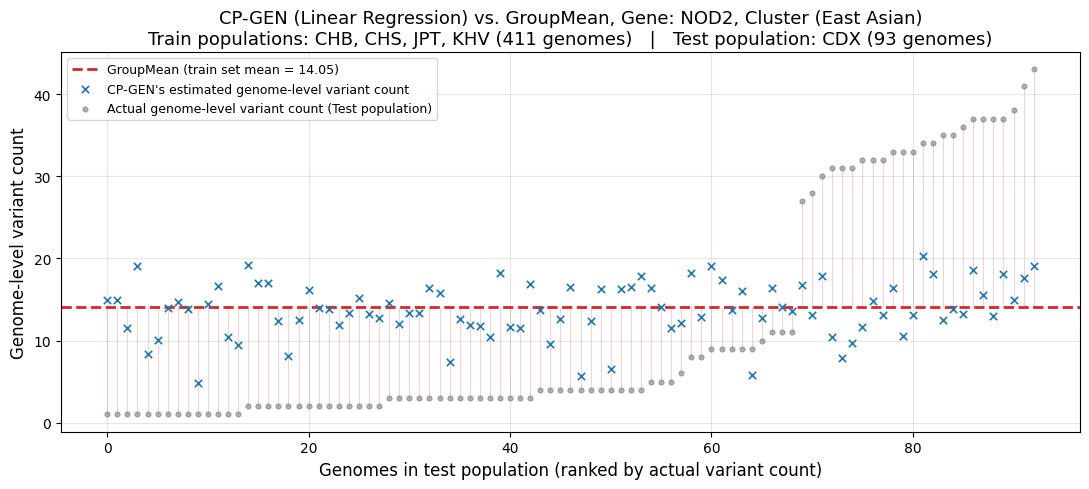

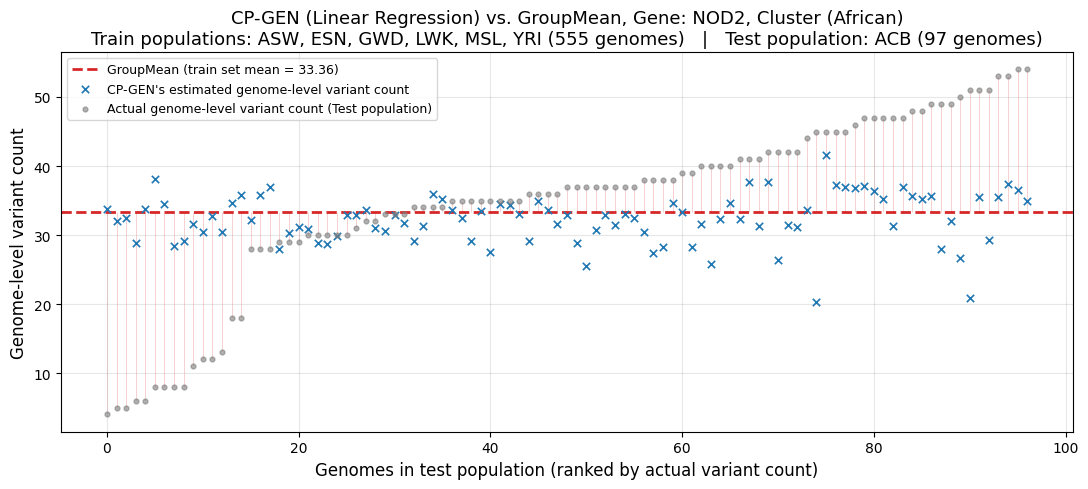

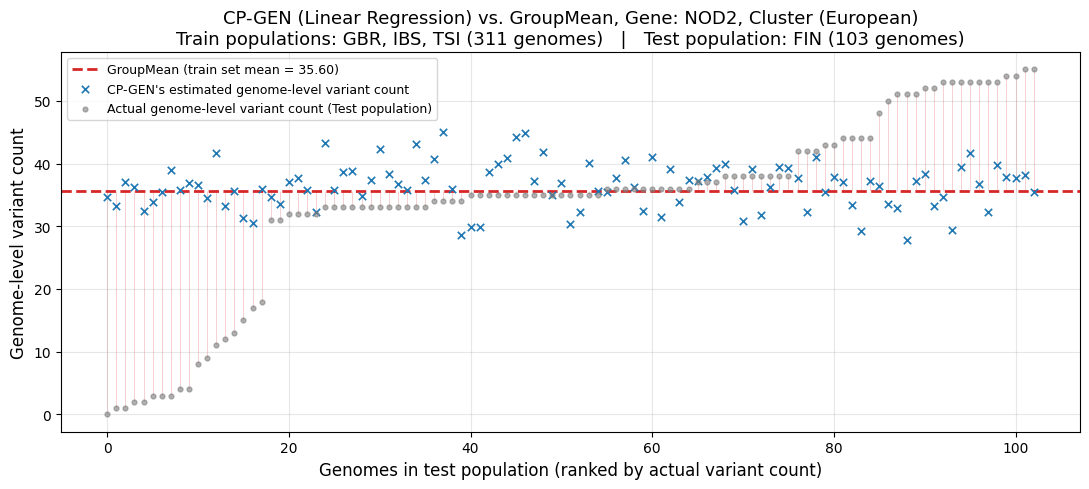

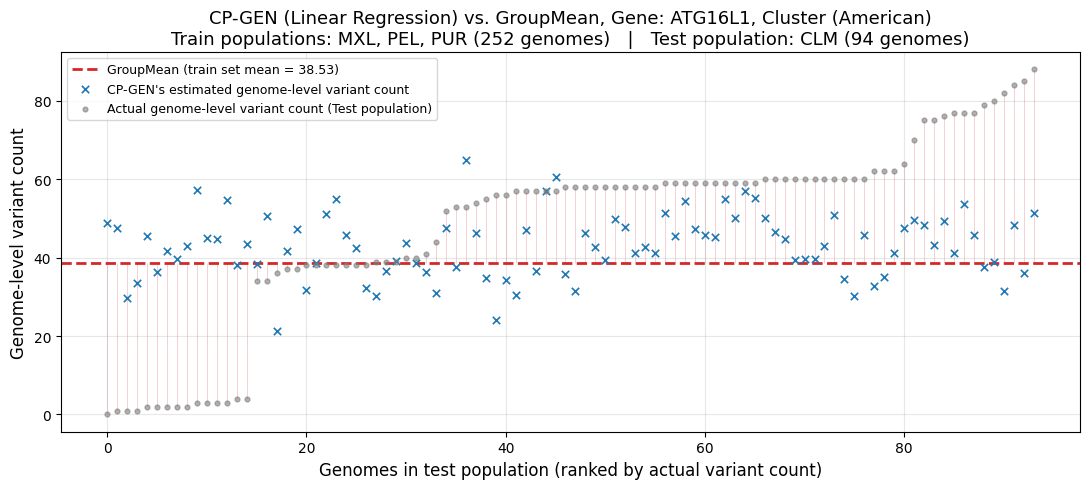

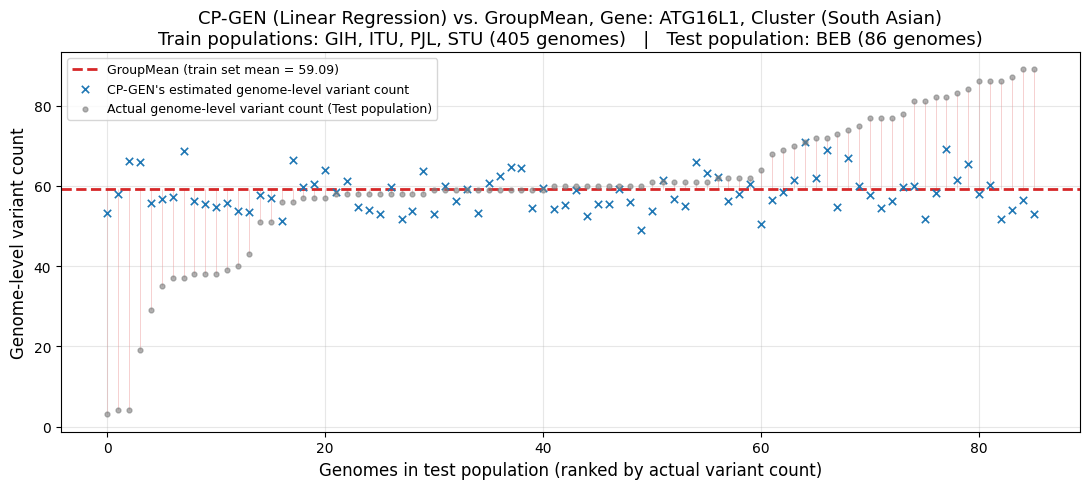

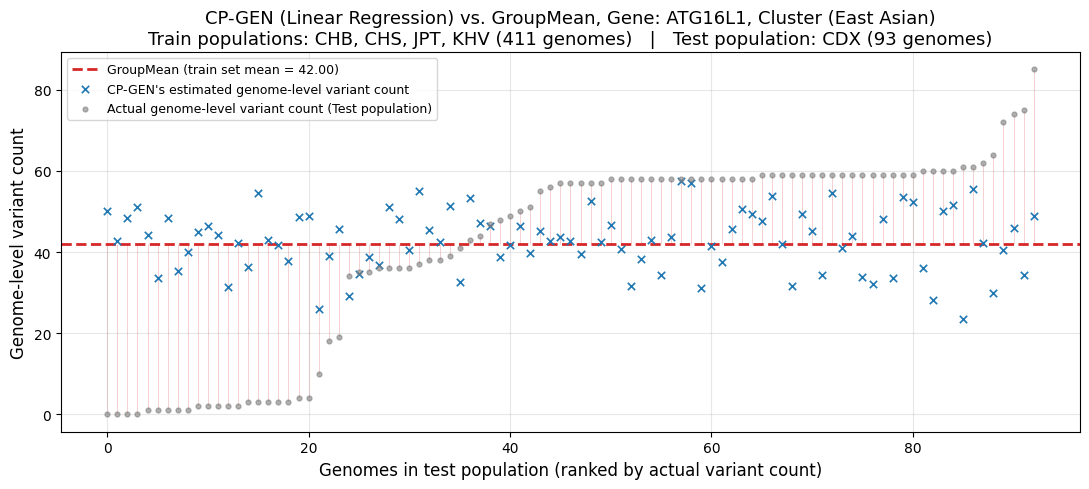

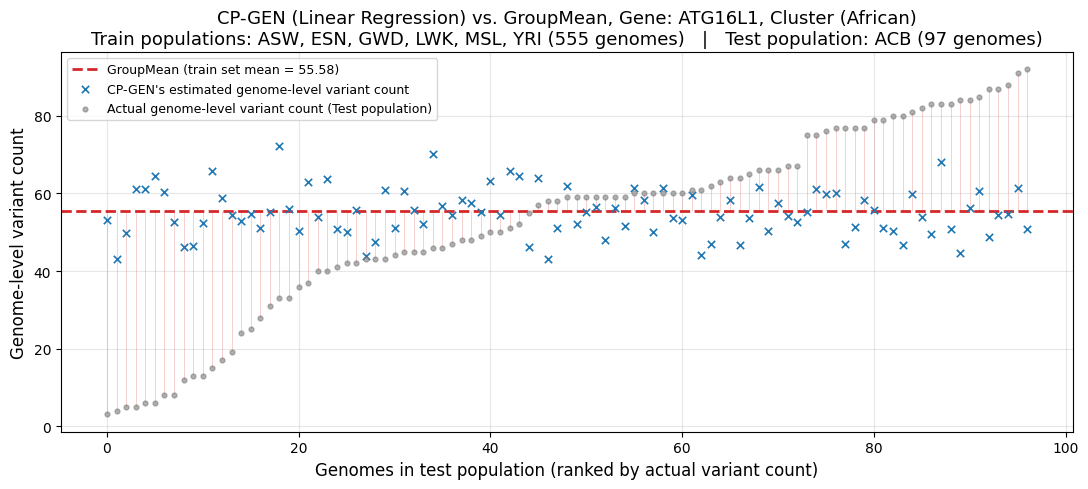

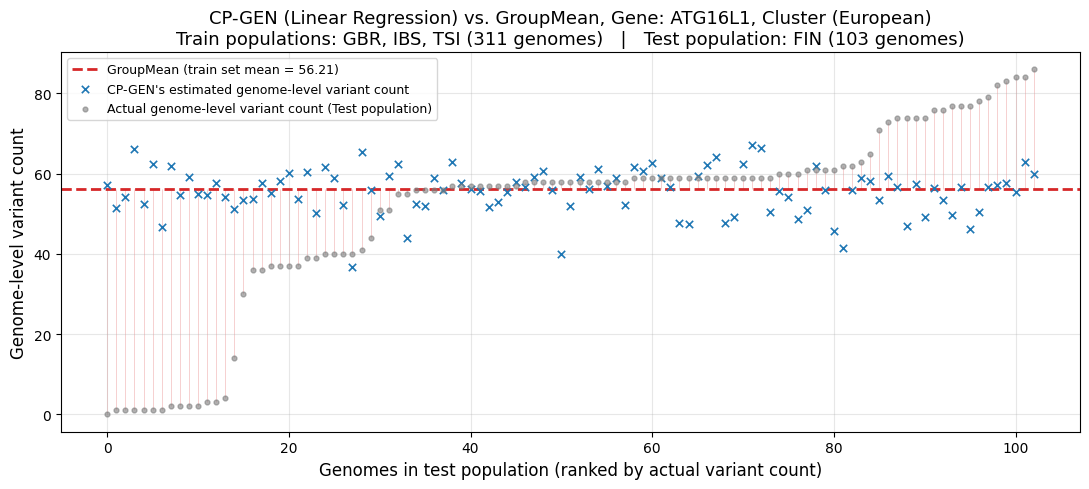

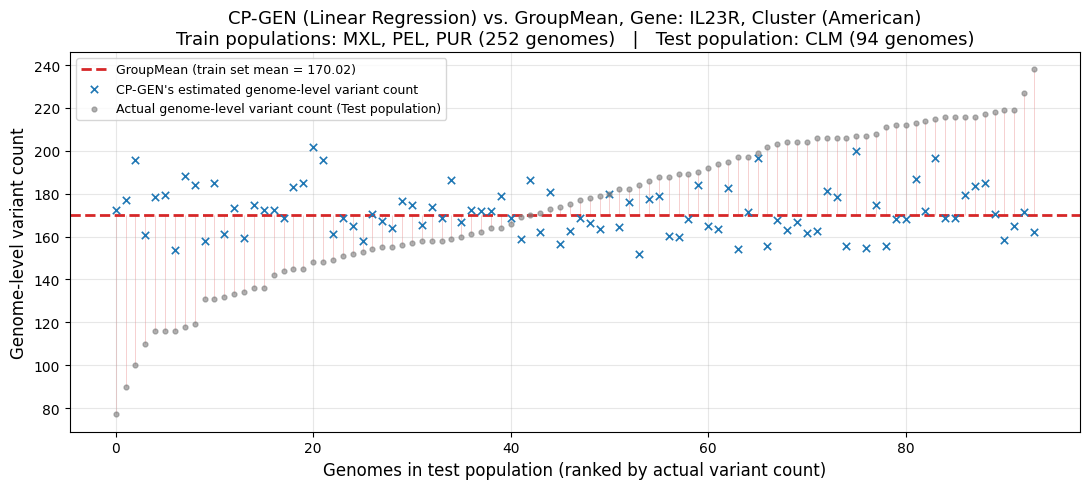

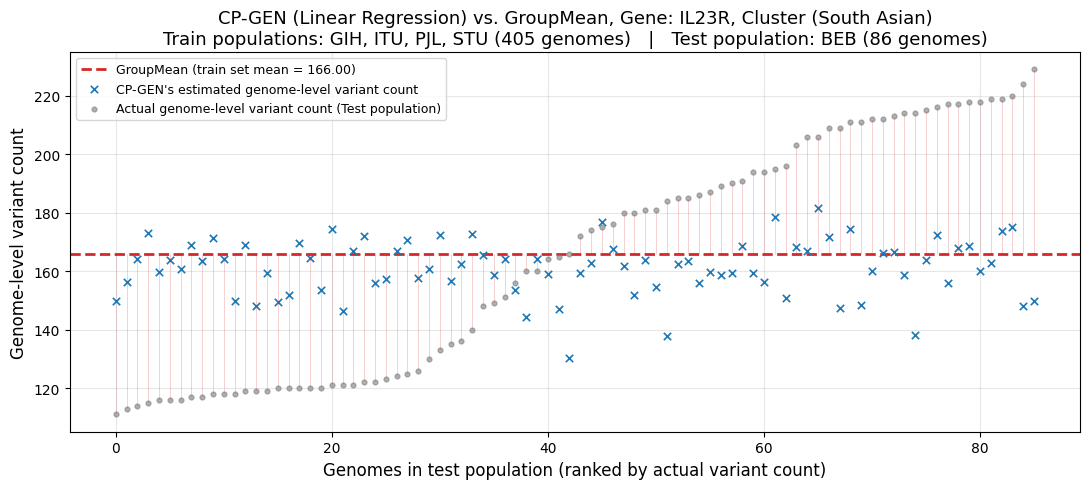

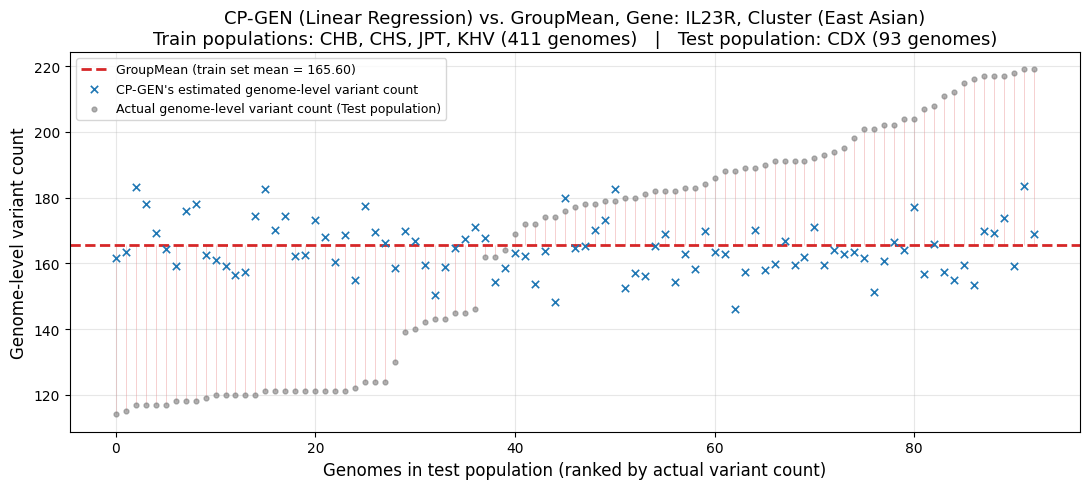

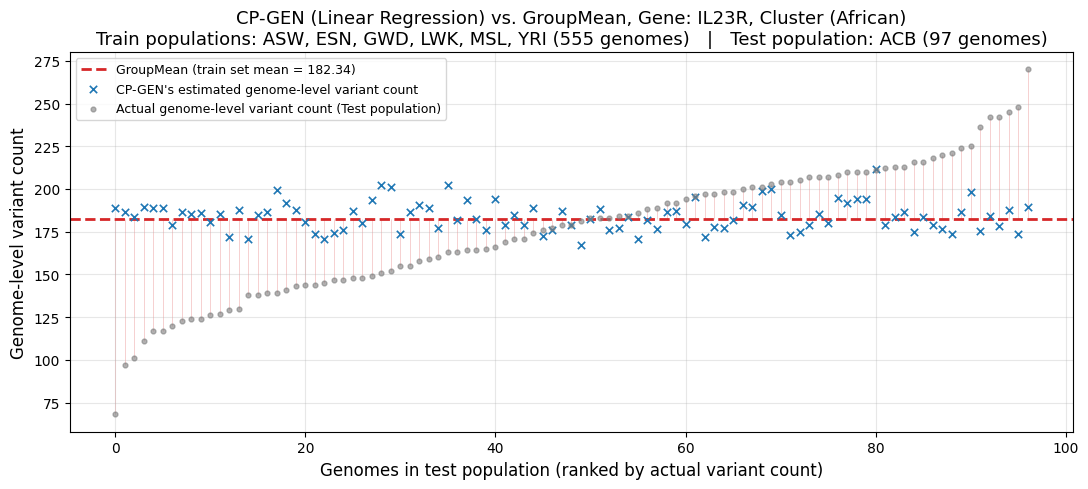

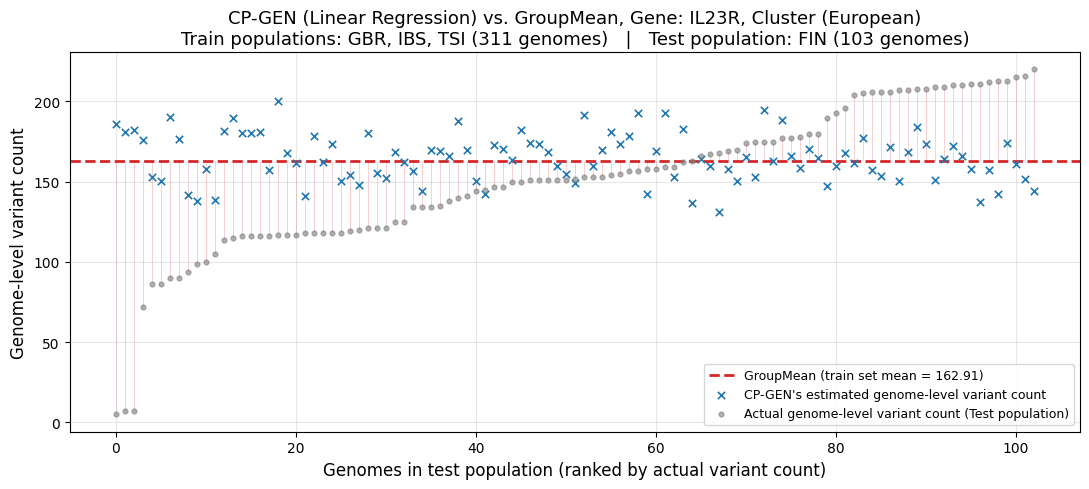

[NOD2/Random Forest] Cluster 0 test=PUR: 104 genomes | saved plot/NOD2_per_genome_RandomForest_cluster0_American_PUR.png


[NOD2/Random Forest] Cluster 1 test=BEB: 86 genomes | saved plot/NOD2_per_genome_RandomForest_cluster1_South_Asian_BEB.png
[NOD2/Random Forest] Cluster 1 test=GIH: 106 genomes | saved plot/NOD2_per_genome_RandomForest_cluster1_South_Asian_GIH.png
[NOD2/Random Forest] Cluster 1 test=ITU: 101 genomes | saved plot/NOD2_per_genome_RandomForest_cluster1_South_Asian_ITU.png


[NOD2/Random Forest] Cluster 1 test=PJL: 96 genomes | saved plot/NOD2_per_genome_RandomForest_cluster1_South_Asian_PJL.png
[NOD2/Random Forest] Cluster 1 test=STU: 102 genomes | saved plot/NOD2_per_genome_RandomForest_cluster1_South_Asian_STU.png


[NOD2/Random Forest] Cluster 2 test=CDX: 93 genomes | saved plot/NOD2_per_genome_RandomForest_cluster2_East_Asian_CDX.png
[NOD2/Random Forest] Cluster 2 test=CHB: 102 genomes | saved plot/NOD2_per_genome_RandomForest_cluster2_East_Asian_CHB.png
[NOD2/Random Forest] Cluster 2 test=CHS: 105 genomes | saved plot/NOD2_per_genome_RandomForest_cluster2_East_Asian_CHS.png


[NOD2/Random Forest] Cluster 2 test=JPT: 105 genomes | saved plot/NOD2_per_genome_RandomForest_cluster2_East_Asian_JPT.png
[NOD2/Random Forest] Cluster 2 test=KHV: 99 genomes | saved plot/NOD2_per_genome_RandomForest_cluster2_East_Asian_KHV.png


...

[IL23R/Linear Regression] Cluster 3 test=ACB: 97 genomes | saved plot/IL23R_per_genome_LinearRegression_cluster3_African_ACB.png
[IL23R/Linear Regression] Cluster 3 test=ASW: 54 genomes | saved plot/IL23R_per_genome_LinearRegression_cluster3_African_ASW.png
[IL23R/Linear Regression] Cluster 3 test=ESN: 100 genomes | saved plot/IL23R_per_genome_LinearRegression_cluster3_African_ESN.png


[IL23R/Linear Regression] Cluster 3 test=GWD: 111 genomes | saved plot/IL23R_per_genome_LinearRegression_cluster3_African_GWD.png
[IL23R/Linear Regression] Cluster 3 test=LWK: 98 genomes | saved plot/IL23R_per_genome_LinearRegression_cluster3_African_LWK.png
[IL23R/Linear Regression] Cluster 3 test=MSL: 90 genomes | saved plot/IL23R_per_genome_LinearRegression_cluster3_African_MSL.png


[IL23R/Linear Regression] Cluster 3 test=YRI: 102 genomes | saved plot/IL23R_per_genome_LinearRegression_cluster3_African_YRI.png


[IL23R/Linear Regression] Cluster 4 test=FIN: 103 genomes | saved plot/IL23R_per_genome_LinearRegression_cluster4_European_FIN.png
[IL23R/Linear Regression] Cluster 4 test=GBR: 96 genomes | saved plot/IL23R_per_genome_LinearRegression_cluster4_European_GBR.png


[IL23R/Linear Regression] Cluster 4 test=IBS: 107 genomes | saved plot/IL23R_per_genome_LinearRegression_cluster4_European_IBS.png
[IL23R/Linear Regression] Cluster 4 test=TSI: 108 genomes | saved plot/IL23R_per_genome_LinearRegression_cluster4_European_TSI.png


In [6]:
# --- Plot styling (tweak here) ---
TITLE_FONTSIZE = 13
AXIS_LABEL_FONTSIZE = 12
CPGEN_DOT_SIZE = 28      # CP-GEN 'x' markers
ACTUAL_DOT_SIZE = 12     # Actual 'o' markers

for gene in target_genes:
    for model_slug, model_name, factory in model_configs:
        for cid, pops in clusters.items():
            res = predict_cluster(pops, gene, factory)
            if res.empty:
                print(f"[{gene}/{model_name}] Cluster {cid}: skipped (needs >=2 populations)")
                continue

            label = cluster_labels.get(cid, str(cid))
            total_genomes = len(res)  # all genomes in this cluster
            # one plot per held-out TEST population (test set = a single population, < ~200 genomes)
            for test_pop, sub in res.groupby('test_population', sort=False):
                # sort genomes by ACTUAL variant count so the actual forms a rising curve
                sub = sub.sort_values('actual').reset_index(drop=True)
                x = np.arange(len(sub))
                group_mean = sub['group_mean'].iloc[0]
                train_pops = [p for p in pops if p != test_pop]
                n_train = total_genomes - len(sub)  # train genomes for this fold

                # error metrics vs the actual genome-level variant count
                rmse_cpgen = np.sqrt(np.mean((sub['actual'] - sub['cpgen']) ** 2))
                rmse_gmean = np.sqrt(np.mean((sub['actual'] - group_mean) ** 2))

                fig, ax = plt.subplots(figsize=(11, 5))
                # residual segments: GroupMean line -> each actual point (the error GroupMean makes)
                ax.vlines(x, np.minimum(sub['actual'], group_mean), np.maximum(sub['actual'], group_mean),
                          color='#d62728', lw=0.6, alpha=0.25, zorder=1)
                ax.axhline(group_mean, color='#d62728', lw=2, ls='--', zorder=2,
                           label=f'GroupMean (train set mean = {group_mean:.2f})')
                ax.scatter(x, sub['cpgen'], s=CPGEN_DOT_SIZE, marker='x', linewidths=1.2, color='#1f77b4', zorder=3,
                           label="CP-GEN's estimated genome-level variant count")
                ax.scatter(x, sub['actual'], s=ACTUAL_DOT_SIZE, marker='o', color='#7f7f7f', alpha=0.6, zorder=4,
                           label='Actual genome-level variant count (Test population)')

                ax.set_title(f'CP-GEN ({model_name}) vs. GroupMean, Gene: {gene}, Cluster ({label})\n'
                             f'Train populations: {", ".join(train_pops)} ({n_train} genomes)   |   '
                             f'Test population: {test_pop} ({len(sub)} genomes)',
                             fontsize=TITLE_FONTSIZE)
                ax.set_xlabel('Genomes in test population (ranked by actual variant count)', fontsize=AXIS_LABEL_FONTSIZE)
                ax.set_ylabel('Genome-level variant count', fontsize=AXIS_LABEL_FONTSIZE)
                ax.legend(loc='best', fontsize=9)
                ax.grid(True, alpha=0.3)
                fig.tight_layout()

                # out = plot_dir / f'{gene}_per_genome_{model_slug}_cluster{cid}_{label.replace(" ", "_")}_{test_pop}.png'
                # fig.savefig(out, dpi=150)
                # plt.close(fig)
                # print(f"[{gene}/{model_name}] Cluster {cid} test={test_pop}: {len(sub)} genomes | saved {out}")
                plt.show()
                break